# Solve 1D Wave equation: 
\begin{equation}
\begin{cases} 
    u_{tt}(x,t) - 4u_{xx}(x,t) = 0 \quad x \in [0, 1], \ t \in [0, 1] \\ 
    u(0,t) = u(1,t) = 0 \\ 
    u_{t}(x,0) = 0 \\ 
    u(x,0) = \sin(\pi x) + \frac{1}{2} \sin(4\pi x) 
\end{cases}
\end{equation} 
$$
u(x,t) = \sin(\pi x) \cos(2\pi t) + \frac{1}{2} \sin(4\pi x) \cos(8\pi t)  
$$

In [3]:
import torch 
from torch import nn 
from collections import OrderedDict # To place the hidden layers orderly 

import numpy as np 
import matplotlib.pyplot as plt 
from mpl_toolkits.axes_grid1 import make_axes_locatable # allows you to easily add new axes next to an existing plot (for example, a colorbar or an inset plot).
from utils.PINN_structure import * 
from utils.data import * 
from Wave_utils import * 
import warnings

warnings.filterwarnings('ignore') # Import the built-in Python warnings module, and tell Python to ignore all warning messages.”
import time 

In [4]:
# MPS or CUDA or CPU 
if torch.backends.mps.is_available(): 
    device = torch.device('mps') 
elif torch.cuda.is_available():
    device = torch.device('cuda') 
else:
    device = torch.device('cpu') 
# 
print(f"Working on {device}") 

Working on mps


# Physics-informed Neural Network 

In [3]:
# The deep neural network
class DNN(nn.Module):
    def __init__(self, layers): 
        super(DNN, self).__init__() 

        # Parameters 
        self.depth = len(layers) - 1 # total layers, including the input and output layers 

        # Set up layer order dict 
        self.activation = nn.Tanh 

        layer_list = list() 
        for i in range(self.depth - 1): 
            layer_list.append(
                ('layer_%d' % i, nn.Linear(layers[i], layers[i+1])) 
            )
            layer_list.append(('activation_%d' % i, self.activation())) 
        
        layer_list.append(
            ('layer_%d' % (self.depth - 1), nn.Linear(layers[-2], layers[-1])) 
        ) 
        layerDict = OrderedDict(layer_list) 

        # deploy layers 
        self.layers = nn.Sequential(layerDict) 

    def forward(self, x): # input data: including spatial and temporal grid points 
        out = self.layers(x) 
        return out 
        

In [5]:
# the physics-informed neural network 
class PINN_Wave(): 
    def __init__(self, X, X_init, u_init, t_bc, layers, lb, ub): 
        # boundary conditions: domain bounds 
        self.lb = torch.tensor(lb).float().to(device) 
        self.ub = torch.tensor(ub).float().to(device) 

        # Training points  
        self.x = torch.tensor(X[:, 0:1], requires_grad = True).float().to(device) # spatial points 
        self.t = torch.tensor(X[:, 1:2], requires_grad = True).float().to(device) # temporal points 

        # Initial data 
        self.x_init = torch.tensor(X_init[:]).float().to(device) # initial data points 
        self.x_init.requires_grad_(True) 
        self.t_init = torch.zeros_like(self.x_init).float().to(device) # t = 0 
        self.t_init.requires_grad_(True) 
        self.u_init = torch.tensor(u_init).float().to(device)

        # Boundary data points 
        self.t_bc = torch.tensor(t_bc).float().to(device) 
        self.x_left = self.lb[0] * torch.ones_like(self.t_bc) 
        self.x_right = self.ub[0] * torch.ones_like(self.t_bc) 
               
        # Regularization parameter
        self.lambda1 = 1.0 
        self.lambda2 = 1.0 
        self.lambda3 = 1.0 

        # deep neural network 
        self.dnn = DNN(layers).to(device) 

        # optimizers: using the same settings 
        self.optimizer = torch.optim.LBFGS( # requires multiple evaluation of the loss function per iteration 
            self.dnn.parameters(),    # target to be optimized 
            lr = 1.0,    # learning rate: step length 
            max_iter = 1,    # maximum number of iterations 
            max_eval = 50000,    # total number of times the closure (loss + backward pass) can be called 
            history_size = 50, 
            tolerance_grad = 1e-7, 
            tolerance_change = 1e-9,
            line_search_fn = "strong_wolfe"      # "strong wolfe condition
        ) 
        
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(), lr = 2e-4, betas = (0.9, 0.999))
        self.iter = 0 

    def net_u(self, x, t): # predicted value 
        u = self.dnn(torch.cat([x, t], dim = 1)) 
        return u 

    def net_f(self, x, t): 
        u = self.net_u(x, t) 

        u_x = torch.autograd.grad(
            u, x, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True
        )[0]

        u_xx = torch.autograd.grad(
            u_x, x, 
            grad_outputs = torch.ones_like(u_x),  
            create_graph = True
        )[0] 

        u_t = torch.autograd.grad( 
            u, t, 
            grad_outputs = torch.ones_like(u), 
            create_graph = True 
        )[0] 

        u_tt = torch.autograd.grad(
            u_t, t, 
            grad_outputs = torch.ones_like(u_t), 
            create_graph = True
        )[0] 
        

        # PDE residual loss 
        f = u_tt - 4 * u_xx 
        return f 

    # Initial data loss 
    def Init_loss_func(self): 
        u0 = self.net_u(self.x_init, self.t_init) 
        u0_t = torch.autograd.grad( 
            u0, self.t_init, 
            grad_outputs = torch.ones_like(u0), 
            create_graph = True 
        )[0] 
        Init_loss = (torch.mean(torch.pow(self.u_init - u0, 2)) + torch.mean(torch.pow(u0_t, 2))) * self.lambda1  
        return Init_loss 
    
    # Boundary data loss 
    def Bc_loss_func(self):
        u_left = self.net_u(self.x_left, self.t_bc) 
        u_right = self.net_u(self.x_right, self.t_bc) 
        bc_loss = (torch.mean(torch.pow(u_left, 2)) + torch.mean(torch.pow(u_right, 2))) * self.lambda2 
        return bc_loss 

    def loss_func(self): 
        f_pred = self.net_f(self.x, self.t) 
        loss = torch.mean(f_pred ** 2) * self.lambda3 + self.Bc_loss_func() + self.Init_loss_func() 
        return loss 
        
    def closure(self): 
        loss_value = self.loss_func() 
        self.optimizer.zero_grad()                             # reset gradients
        loss_value.backward()                                  # compute gradients but only the network weights will be updated 
        return loss_value  

    def train(self, nIter1, nIter2 = 2000):
        self.dnn.train()
        # Backward and optimize: 2nd phase optimization 
        # Two Phase optimization 
        for epoch in range(nIter1):
            # PDE loss 
            f_pred = self.net_f(self.x, self.t)

            # data loss: Boundary condition mismatch 
            bc_loss = self.Bc_loss_func() 
            # bc_loss = self.bc_loss_func()
            
            # data loss: Initial condition mismatch 
            ic_loss = self.Init_loss_func() 
            
            # total loss: IC+ BC + PDE 
            loss =  torch.mean(torch.pow(f_pred, 2)) + bc_loss + ic_loss 

            # Backward and optimize 
            self.optimizer_Adam.zero_grad()
            loss.backward()
            self.optimizer_Adam.step()            
            if epoch % 100 == 0: 
                print(
                    'It: %d, Loss: %.3e' % 
                    ( 
                        epoch, 
                        loss.item()
                    )
                )
        # Second Phase Optimization         
        for i in range(nIter2):
            loss_value = self.optimizer.step(self.closure) # Never pass tensors into optimizer.step
            self.iter += 1
            if self.iter % 100 == 0:
                print('It: %d, Loss: %e' % (self.iter, loss_value.item()))
        
    # def predict(self, X, X_bc, T_bc):
    def predict(self, X):
        x = torch.tensor(X[:, 0:1], requires_grad = True).float().to(device) 
        t = torch.tensor(X[:, 1:2], requires_grad = True).float().to(device) 
        
        self.dnn.eval()

        u = self.net_u(x, t) 
        f = self.net_f(x, t) 
        
        u = u.detach().cpu().numpy()
        f = f.detach().cpu().numpy() 
        
        return u, f 

# Configurations 

In [8]:
# Domain bounds 
lb = np.array([0.0, 0.0]) # second element for time 
ub = np.array([1.0, 1.0]) # second element for time                                                

# Grid point setup 
N_bc = 100
Nx_int = 50
Nt_int = 100 
N_init = 100  

# Training points
X_train_int = interior_points(Nx_int, Nt_int, lb[0], ub[0], lb[1], ub[1]) 
print(f"X_train_int shape: {np.shape(X_train_int)}")

X_train_init = init_points(N_init, lb[0], ub[0]) 
U_train_init = u_0(X_train_init)
print('X_train_init shape: ', np.shape(X_train_init)) 
print('U_train_init shape: ', np.shape(U_train_init)) 

T_bc = bc_points(N_bc, lb[1], ub[1])
print('T_bc shape: ', np.shape(T_bc)) 

X_train_int shape: (5000, 2)
X_train_init shape:  (100, 1)
U_train_init shape:  (100, 1)
T_bc shape:  (100, 1)


# Generate Test data and solution  

In [9]:
Nx = 200; Nt = 50 
X_test, u_test = test_data(Nx, Nt, lb[0], ub[0], lb[1], ub[1])

print(f"X_test shape: {X_test.shape}") 
print(f"u_test shape: {u_test.shape}") 

X_test shape: (10000, 2)
u_test shape: (10000, 1)


# Training on non-noisy data 

In [11]:
noise = 0.0 
layers = [2] + [30] * 12 + [1] 
model = PINN_Wave(X_train_int, X_train_init, U_train_init, T_bc, layers, lb, ub) 
# training
start = time.time()
model.train(3000, 1500)
end = time.time()

It: 0, Loss: 5.158e-01
It: 100, Loss: 4.027e-01
It: 200, Loss: 3.676e-01
It: 300, Loss: 3.509e-01
It: 400, Loss: 3.042e-01
It: 500, Loss: 2.747e-01
It: 600, Loss: 2.438e-01
It: 700, Loss: 2.070e-01
It: 800, Loss: 1.921e-01
It: 900, Loss: 1.878e-01
It: 1000, Loss: 1.771e-01
It: 1100, Loss: 1.721e-01
It: 1200, Loss: 1.681e-01
It: 1300, Loss: 1.707e-01
It: 1400, Loss: 1.633e-01
It: 1500, Loss: 1.615e-01
It: 1600, Loss: 1.605e-01
It: 1700, Loss: 1.603e-01
It: 1800, Loss: 1.600e-01
It: 1900, Loss: 1.586e-01
It: 2000, Loss: 1.762e-01
It: 2100, Loss: 1.578e-01
It: 2200, Loss: 1.575e-01
It: 2300, Loss: 1.730e-01
It: 2400, Loss: 1.567e-01
It: 2500, Loss: 1.564e-01
It: 2600, Loss: 1.563e-01
It: 2700, Loss: 1.559e-01
It: 2800, Loss: 1.556e-01
It: 2900, Loss: 1.555e-01
It: 100, Loss: 1.513402e-01
It: 200, Loss: 1.489977e-01
It: 300, Loss: 1.465523e-01
It: 400, Loss: 1.402385e-01
It: 500, Loss: 1.354590e-01
It: 600, Loss: 1.322512e-01
It: 700, Loss: 1.292099e-01
It: 800, Loss: 1.274363e-01
It: 900,

In [12]:
# evaluations 
u_pred, f_pred = model.predict(X_test) 
print(f"u_pred shape: {np.shape(u_pred)}") 
print(f"f_pred shape: {np.shape(f_pred)}") 


error_u = np.linalg.norm(u_test - u_pred, 2) / np.linalg.norm(u_test, 2) # relative L^{2} square norm 
error_f = np.linalg.norm(f_pred, ord = np.inf) 

print('Error u: %e' % (error_u)) 
print('PDE loss: %e' % (error_f)) 
print(f'Training time is {end-start:.2f} seconds')

u_pred shape: (10000, 1)
f_pred shape: (10000, 1)
Error u: 4.770695e-01
PDE loss: 6.261177e-01
Training time is 337.68 seconds


# Collecting Error Data 

In [20]:
noise = 0.0 
err_l2 = np.zeros([10]) 
err_linf = np.zeros([10]) 
Training_time = np.zeros([10]) 
 
layers = [2] + [30] * 12 + [1] 

training_sets = np.load(
    "Wave_Equation_training_points_sets.npy",
    allow_pickle=True
)


for k in range(10): 
    data = training_sets[k] 
    X_train_int = data["X_train_int"] 
    X_train_init = data["X_train_init"] 
    U_train_init = u_0(X_train_init)
    T_bc = data["T_bc"]
    model = PINN_Wave(X_train_int, X_train_init, U_train_init, T_bc, layers, lb, ub) 
    start = time.time() 
    model.train(3000, 1500) 
    end = time.time() 
    u_pred, f_pred = model.predict(X_test) 
    err_l2[k] = np.linalg.norm(abs(u_test - u_pred), 2) / np.linalg.norm(u_test, 2) 
    err_linf[k] = np.max(np.abs(u_test - u_pred))
    Training_time[k] = (end - start) 
    

It: 0, Loss: 1.001e+00
It: 100, Loss: 4.643e-01
It: 200, Loss: 4.097e-01
It: 300, Loss: 4.029e-01
It: 400, Loss: 3.955e-01
It: 500, Loss: 3.798e-01
It: 600, Loss: 3.644e-01
It: 700, Loss: 3.602e-01
It: 800, Loss: 3.586e-01
It: 900, Loss: 3.583e-01
It: 1000, Loss: 3.573e-01
It: 1100, Loss: 3.566e-01
It: 1200, Loss: 3.575e-01
It: 1300, Loss: 3.561e-01
It: 1400, Loss: 3.570e-01
It: 1500, Loss: 3.557e-01
It: 1600, Loss: 3.578e-01
It: 1700, Loss: 3.557e-01
It: 1800, Loss: 3.550e-01
It: 1900, Loss: 3.555e-01
It: 2000, Loss: 3.547e-01
It: 2100, Loss: 3.555e-01
It: 2200, Loss: 3.544e-01
It: 2300, Loss: 3.567e-01
It: 2400, Loss: 3.541e-01
It: 2500, Loss: 3.634e-01
It: 2600, Loss: 3.537e-01
It: 2700, Loss: 3.527e-01
It: 2800, Loss: 3.538e-01
It: 2900, Loss: 3.521e-01
It: 100, Loss: 3.460553e-01
It: 200, Loss: 3.412901e-01
It: 300, Loss: 3.378418e-01
It: 400, Loss: 3.361817e-01
It: 500, Loss: 3.350406e-01
It: 600, Loss: 3.338991e-01
It: 700, Loss: 3.332331e-01
It: 800, Loss: 3.332331e-01
It: 900,

In [21]:
print("err_l2 mean: ", np.mean(err_l2))
print("err_linf mean: ", np.mean(err_linf)) 
print("err_l2 std: ", np.std(err_l2)) 
print("err_linf std: ", np.std(err_linf))

err_l2 mean:  0.9511949103995587
[1.00059735 0.97446653 0.75870253 0.97325733 0.97193253 0.97245166
 0.95314775 0.96410531 0.969371   0.97391712]
0.06513163293892564
err_linf mean:  1.4263924288284784
0.06804382970344115
Training_time mean:  466.08974516391754
28.905785882083983


In [22]:
# Save the results 
results = {
    "Model": "PINN",
    "num_features": layers, 
    "Training_points_int_bc": [Nx_int, Nt_int, N_init, N_bc], 
    "L2_error": err_l2,
    "Linf_error": err_linf,  
    "Training_time": Training_time,
}

# torch.save(results, "Wave_PINN_5000_training_points_data.pt")

# Visualization 

' \nfig.subplots_adjust(\n    wspace=0.08,\n    bottom=0.25\n)\n'

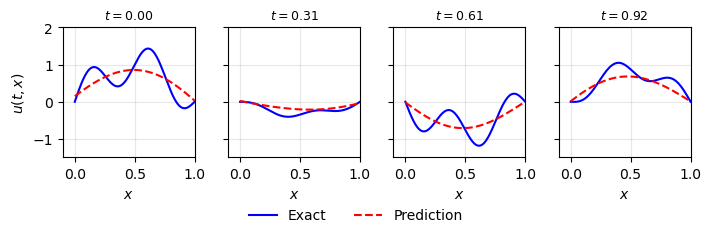

In [13]:
import matplotlib.gridspec as gridspec 

fig, axes = plt.subplots(
    1, 4,
    figsize=(7, 2),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'wspace': 0.1}
)
# fig.subplots_adjust(wspace=0.1)

times = [0, 15, 30, 45]

for ax, idx in zip(axes, times):
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_test[idx*Nx:(idx+1)*Nx],
        'b-',
        linewidth=1.5,
        label='Exact'
    )
    ax.plot(
        X_test[idx*Nx:(idx+1)*Nx, 0:1],
        u_pred[idx*Nx:(idx+1)*Nx,0],
        'r--',
        linewidth=1.5,
        label='Prediction'
    )

    ax.set_title(
        rf'$t={X_test[idx * Nx, 1]:.2f}$',
        fontsize=9
    )

    ax.set_xlim([-0.1,1.0])
    ax.set_ylim([-1.5,2.0])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$u(t,x)$')
for ax in axes:
    ax.set_xlabel(r'$x$')
""" 
axes[1].legend(
    loc='lower center',
    bbox_to_anchor=(0.5,-0.75),
    ncol=2,
    frameon=False
)
"""
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)
""" 
fig.subplots_adjust(
    wspace=0.08,
    bottom=0.25
)
""" 
# fig.savefig("Wave_PINN.png", dpi=300, bbox_inches='tight')